In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl

from scipy.spatial.distance import squareform
import plotly.graph_objects as go
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.cluster.hierarchy import cophenet, fcluster
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import pdist, squareform

from src.datasets import MaterialsProject

from scripts.materials_project.evaluation_pipeline import (run_evaluation, 
                                                           hierachial_clustering, 
                                                           get_overall_chemical_coherence, 
                                                           get_distance_matrices,
                                                           build_invariant_matrix
                                                           )
from src.helper_functions import create_chemiscope_viewer

In [3]:
mp = MaterialsProject(add_soap=True, add_acsf=False, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"])
df = mp.load(limit=1000)

2026-03-31 19:38:17.836 | INFO     | src.datasets:load:1055 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 19:38:18.680 | INFO     | src.datasets:load:1085 - Sampling 1000 rows using stratified strategy...
2026-03-31 19:38:18.827 | INFO     | src.datasets:load:1102 - Computing descriptors on sampled subset (1000 rows) and saving to tagged cache: sample_n1000_seed40_stratified
2026-03-31 19:38:18.827 | INFO     | src.datasets:_add_descriptors:1346 - Ignoring output_tag=sample_n1000_seed40_stratified since descriptors are not saved to disk.
2026-03-31 19:38:18.827 | INFO     | src.datasets:_add_descriptors:1349 - Extracting unique elements from formulas...
2026-03-31 19:38:34.831 | INFO     | src.datasets:_add_descriptors:1359 - Found 85 unique elements. Warning: Feature vectors will be massive.
2026-03-31 19:38:34.833 | INFO     | src.datasets:_add_descriptors:1390 - Computing SOAP chunk 0 (0 to 1000)...
2026-03-31 19:38:37.232 | SUCCESS  

# Average

Silhouette Score: 0.7475
Davies-Bouldin Score: 0.3586


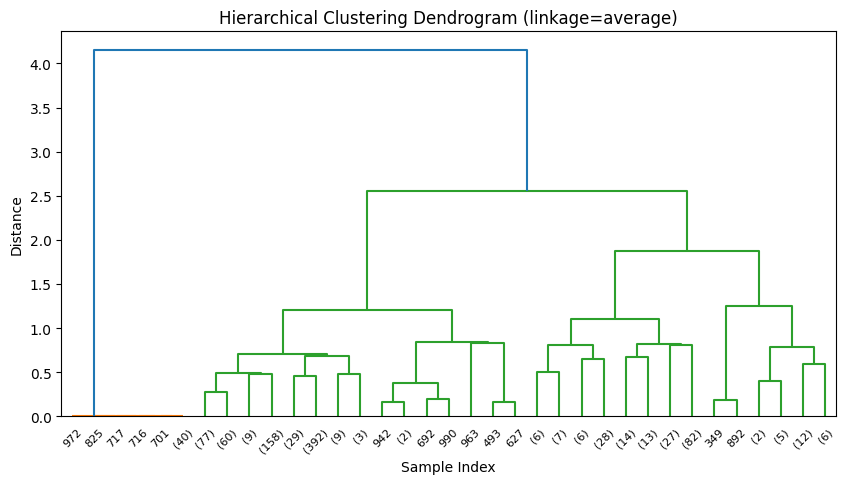

In [5]:
linkage = 'average'
feature_keys = ['avg_neighbor_dist']
raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=feature_keys)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(np.array(raw_matrix))

# 2. Compute Distances and Linkage
dist_condensed = pdist(scaled_matrix, metric='euclidean')
Z = scipy_linkage(dist_condensed, method=linkage)
k = 3
labels = fcluster(Z, k, criterion='maxclust')
sil = silhouette_score(scaled_matrix, labels)
db = davies_bouldin_score(scaled_matrix, labels)

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
# 3. Plot Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title(f'Hierarchical Clustering Dendrogram (linkage={linkage})')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 4. Create Chemiscope Viewer
df = df.with_columns(pl.Series(name='cluster', values=labels))

In [6]:
create_chemiscope_viewer(df,  squareform(dist_condensed), labels=labels, reduction_method='t-SNE')

Running t-SNE dimensionality reduction...
Converting Pymatgen structures to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - SOAP t-SNE Clustering'}, settings={'map': {'x': {'propert…

# Complete

Silhouette Score: 0.6971
Davies-Bouldin Score: 0.5589


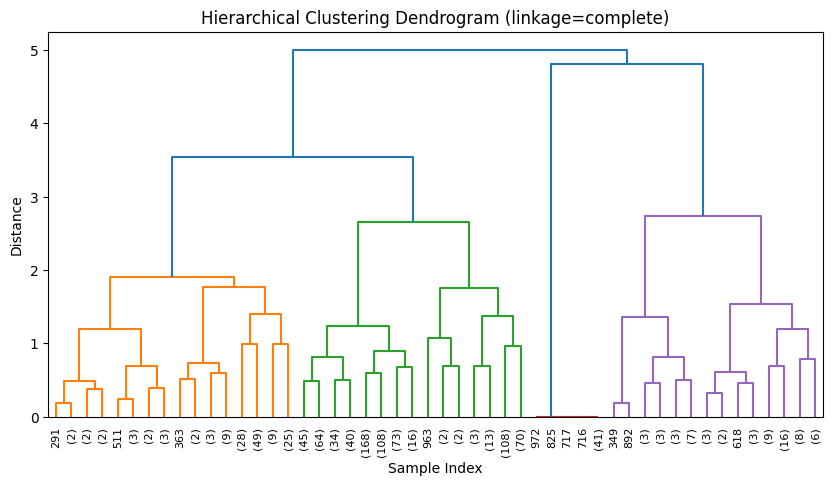

In [14]:
linkage = 'complete'
feature_keys = ['avg_neighbor_dist']
raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=feature_keys)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(np.array(raw_matrix))

# 2. Compute Distances and Linkage
dist_condensed = pdist(scaled_matrix, metric='euclidean')
Z = scipy_linkage(dist_condensed, method=linkage)
k = 4
labels = fcluster(Z, k, criterion='maxclust')
sil = silhouette_score(scaled_matrix, labels)
db = davies_bouldin_score(scaled_matrix, labels)

print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
# 3. Plot Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title(f'Hierarchical Clustering Dendrogram (linkage={linkage})')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 4. Create Chemiscope Viewer
df = df.with_columns(pl.Series(name='cluster', values=labels))

In [16]:
create_chemiscope_viewer(df,  squareform(dist_condensed), labels=labels, reduction_method='t-SNE')

Running t-SNE dimensionality reduction...
Converting Pymatgen structures to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - SOAP t-SNE Clustering'}, settings={'map': {'x': {'propert…